In [1]:
import os
os.chdir("..")
print(os.getcwd())

c:\Users\Landl\Downloads\Data-Science-Projects\sec-financial-nlp


In [2]:
# Cell 1 — the raw structure of one filing
file_path = "data/raw/sec-edgar-filings/AAPL/10-K"

import os

# inside AAPL 10-K folder
for root, dirs, files in os.walk(file_path):
    for f in files:
        print(os.path.join(root, f))

data/raw/sec-edgar-filings/AAPL/10-K\0000320193-20-000096\full-submission.txt
data/raw/sec-edgar-filings/AAPL/10-K\0000320193-21-000105\full-submission.txt
data/raw/sec-edgar-filings/AAPL/10-K\0000320193-22-000108\full-submission.txt
data/raw/sec-edgar-filings/AAPL/10-K\0000320193-23-000106\full-submission.txt
data/raw/sec-edgar-filings/AAPL/10-K\0000320193-24-000123\full-submission.txt


In [3]:
with open("data/raw/sec-edgar-filings/AAPL/10-K/0000320193-24-000123/full-submission.txt", "r", encoding="utf-8") as f:
    content = f.read()

print(len(content))
print(content[:1000])  # Print the first 1000 characters of the content

9759333
<SEC-DOCUMENT>0000320193-24-000123.txt : 20241101
<SEC-HEADER>0000320193-24-000123.hdr.sgml : 20241101
<ACCEPTANCE-DATETIME>20241101060136
ACCESSION NUMBER:		0000320193-24-000123
CONFORMED SUBMISSION TYPE:	10-K
PUBLIC DOCUMENT COUNT:		103
CONFORMED PERIOD OF REPORT:	20240928
FILED AS OF DATE:		20241101
DATE AS OF CHANGE:		20241101

FILER:

	COMPANY DATA:	
		COMPANY CONFORMED NAME:			Apple Inc.
		CENTRAL INDEX KEY:			0000320193
		STANDARD INDUSTRIAL CLASSIFICATION:	ELECTRONIC COMPUTERS [3571]
		ORGANIZATION NAME:           	06 Technology
		IRS NUMBER:				942404110
		STATE OF INCORPORATION:			CA
		FISCAL YEAR END:			0928

	FILING VALUES:
		FORM TYPE:		10-K
		SEC ACT:		1934 Act
		SEC FILE NUMBER:	001-36743
		FILM NUMBER:		241416806

	BUSINESS ADDRESS:	
		STREET 1:		ONE APPLE PARK WAY
		CITY:			CUPERTINO
		STATE:			CA
		ZIP:			95014
		BUSINESS PHONE:		(408) 996-1010

	MAIL ADDRESS:	
		STREET 1:		ONE APPLE PARK WAY
		CITY:			CUPERTINO
		STATE:			CA
		ZIP:			95014

	FORMER COMPANY:	


In [4]:
types = []
for line in content.split("\n"):
    if line.startswith("<TYPE>"):
        types.append(line.replace("<TYPE>", "").strip())

print(types[:10])
print(f"Total documents: {len(types)}")

['10-K', 'EX-4.1', 'EX-10.19', 'EX-10.20', 'EX-10.21', 'EX-10.22', 'EX-19.1', 'EX-21.1', 'EX-23.1', 'EX-31.1']
Total documents: 102


In [5]:
# Extracting the first 10-K document (first document)

start = content.find("<DOCUMENT>")
end = content.find("</DOCUMENT>", start) + len("</DOCUMENT>")

first_doc = content[start:end]
print(len(first_doc))
print(first_doc[:1000])  # Print the first 1000 characters of the first document

1503901
<DOCUMENT>
<TYPE>10-K
<SEQUENCE>1
<FILENAME>aapl-20240928.htm
<DESCRIPTION>10-K
<TEXT>
<XBRL>
<?xml version='1.0' encoding='ASCII'?>
<!--XBRL Document Created with the Workiva Platform-->
<!--Copyright 2024 Workiva-->
<!--r:6516014a-223b-4792-964c-105c0fc62715,g:fb24cc6b-9929-486d-8f15-d4cad8060a59,d:7bfbfbe54b9647b1b4ba4ff4e0aba09d-->
<html xmlns:link="http://www.xbrl.org/2003/linkbase" xmlns:iso4217="http://www.xbrl.org/2003/iso4217" xmlns:country="http://xbrl.sec.gov/country/2024" xmlns="http://www.w3.org/1999/xhtml" xmlns:ixt-sec="http://www.sec.gov/inlineXBRL/transformation/2015-08-31" xmlns:dei="http://xbrl.sec.gov/dei/2024" xmlns:xbrli="http://www.xbrl.org/2003/instance" xmlns:ixt="http://www.xbrl.org/inlineXBRL/transformation/2020-02-12" xmlns:xsi="http://www.w3.org/2001/XMLSchema-instance" xmlns:aapl="http://www.apple.com/20240928" xmlns:ecd="http://xbrl.sec.gov/ecd/2024" xmlns:xlink="http://www.w3.org/1999/xlink" xmlns:xbrldi="http://xbrl.org/2006/xbrldi" xmlns:ix="ht

In [6]:
from bs4 import BeautifulSoup

soup = BeautifulSoup(first_doc, "html.parser")
clean_text = soup.get_text(separator=" ", strip=True)

print(len(clean_text))
print(clean_text[:1000])  # Print the first 1000 characters of the cleaned text

218717
10-K 1 aapl-20240928.htm 10-K aapl-20240928 false 2024 FY 0000320193 P1Y P1Y P1Y P1Y http://fasb.org/us-gaap/2024#MarketableSecuritiesCurrent http://fasb.org/us-gaap/2024#MarketableSecuritiesNoncurrent http://fasb.org/us-gaap/2024#MarketableSecuritiesCurrent http://fasb.org/us-gaap/2024#MarketableSecuritiesNoncurrent http://fasb.org/us-gaap/2024#LongTermDebtCurrent http://fasb.org/us-gaap/2024#LongTermDebtNoncurrent http://fasb.org/us-gaap/2024#LongTermDebtCurrent http://fasb.org/us-gaap/2024#LongTermDebtNoncurrent http://fasb.org/us-gaap/2024#OtherAssetsNoncurrent http://fasb.org/us-gaap/2024#OtherAssetsNoncurrent http://fasb.org/us-gaap/2024#PropertyPlantAndEquipmentNet http://fasb.org/us-gaap/2024#PropertyPlantAndEquipmentNet http://fasb.org/us-gaap/2024#OtherLiabilitiesCurrent http://fasb.org/us-gaap/2024#OtherLiabilitiesCurrent http://fasb.org/us-gaap/2024#OtherLiabilitiesNoncurrent http://fasb.org/us-gaap/2024#OtherLiabilitiesNoncurrent http://fasb.org/us-gaap/2024#OtherLi

In [7]:
position = clean_text.find("Item 1.")
print(position)
print(clean_text[position:position+1000])  # Print 1000 characters around the position

19601
Item 1. Business 1 Item 1A. Risk Factors 5 Item 1B. Unresolved Staff Comments 17 Item 1C. Cybersecurity 17 Item 2. Properties 18 Item 3. Legal Proceedings 18 Item 4. Mine Safety Disclosures 18 Part II Item 5. Market for Registrant’s Common Equity, Related Stockholder Matters and Issuer Purchases of Equity Securities 19 Item 6. [Reserved] 20 Item 7. Management’s Discussion and Analysis of Financial Condition and Results of Operations 21 Item 7A. Quantitative and Qualitative Disclosures About Market Risk 27 Item 8. Financial Statements and Supplementary Data 28 Item 9. Changes in and Disagreements with Accountants on Accounting and Financial Disclosure 51 Item 9A. Controls and Procedures 51 Item 9B. Other Information 52 Item 9C. Disclosure Regarding Foreign Jurisdictions that Prevent Inspections 52 Part III Item 10. Directors, Executive Officers and Corporate Governance 52 Item 11. Executive Compensation 52 Item 12 . Security Ownership of Certain Beneficial Owners and Management an

In [8]:
first_position = clean_text.find("Item 1.")
second_position = clean_text.find("Item 1A.", first_position + 1)

print(second_position)
print(clean_text[second_position:second_position+1500])  # Print text between Item 1 and Item 1A

19620
Item 1A. Risk Factors 5 Item 1B. Unresolved Staff Comments 17 Item 1C. Cybersecurity 17 Item 2. Properties 18 Item 3. Legal Proceedings 18 Item 4. Mine Safety Disclosures 18 Part II Item 5. Market for Registrant’s Common Equity, Related Stockholder Matters and Issuer Purchases of Equity Securities 19 Item 6. [Reserved] 20 Item 7. Management’s Discussion and Analysis of Financial Condition and Results of Operations 21 Item 7A. Quantitative and Qualitative Disclosures About Market Risk 27 Item 8. Financial Statements and Supplementary Data 28 Item 9. Changes in and Disagreements with Accountants on Accounting and Financial Disclosure 51 Item 9A. Controls and Procedures 51 Item 9B. Other Information 52 Item 9C. Disclosure Regarding Foreign Jurisdictions that Prevent Inspections 52 Part III Item 10. Directors, Executive Officers and Corporate Governance 52 Item 11. Executive Compensation 52 Item 12 . Security Ownership of Certain Beneficial Owners and Management and Related Stockhold

In [9]:
position = clean_text.find("designs, manufactures and markets")
print(position)
print(clean_text[position:position+1500])

22900
designs, manufactures and markets smartphones, personal computers, tablets, wearables and accessories, and sells a variety of related services. The Company’s fiscal year is the 52- or 53-week period that ends on the last Saturday of September. Products iPhone iPhone ® is the Company’s line of smartphones based on its iOS operating system. The iPhone line includes iPhone 16 Pro, iPhone 16, iPhone 15, iPhone 14 and iPhone SE ® . Mac Mac ® is the Company’s line of personal computers based on its macOS ® operating system. The Mac line includes laptops MacBook Air ® and MacBook Pro ® , as well as desktops iMac ® , Mac mini ® , Mac Studio ® and Mac Pro ® . iPad iPad ® is the Company’s line of multipurpose tablets based on its iPadOS ® operating system. The iPad line includes iPad Pro ® , iPad Air ® , iPad and iPad mini ® . Wearables, Home and Accessories Wearables includes smartwatches, wireless headphones and spatial computers. The Company’s line of smartwatches, based on its watchOS 

In [10]:
xbrl_end = first_doc.find("</XBRL>")
print(xbrl_end)

1503874


In [11]:
xbrl_start = first_doc.find("<XBRL>")
print(xbrl_start)
print(xbrl_end - xbrl_start)

87
1503787


In [ ]:
# First attempt
def extract_clean_text(filepath, skip_chars=18000):
    with open(filepath, "r", encoding="utf-8") as f:
        content = f.read()

    start = content.find("<DOCUMENT>")
    end = content.find("</DOCUMENT>", start) + len("</DOCUMENT>")

    doc = content[start:end]

    soup = BeautifulSoup(doc, "html.parser")
    clean_text = soup.get_text(separator=" ", strip=True)

    search_zone = clean_text[skip_chars:]
    return search_zone  # Skip the first 18,000 characters

In [13]:
sample = extract_clean_text("data/raw/sec-edgar-filings/AAPL/10-K/0000320193-24-000123/full-submission.txt")
print(len(sample))
print(sample[:1000])

200717
s. ☐ Indicate by check mark whether any of those error corrections are restatements that required a recovery analysis of incentive-based compensation received by any of the registrant’s executive officers during the relevant recovery period pursuant to §240.10D-1(b). ☐ Indicate by check mark whether the Registrant is a shell company (as defined in Rule 12b-2 of the Act). Yes ☐ No ☒ The aggregate market value of the voting and non-voting stock held by non-affiliates of the Registrant, as of March 29, 2024, the last business day of the Registrant’s most recently completed second fiscal quarter, was approximately $ 2,628,553,000,000 . Solely for purposes of this disclosure, shares of common stock held by executive officers and directors of the Registrant as of such date have been excluded because such persons may be deemed to be affiliates. This determination of executive officers and directors as affiliates is not necessarily a conclusive determination for any other purposes. 15,1

In [ ]:
sample_msft = extract_clean_text("data/raw/sec-edgar-filings/MSFT/10-K/0000950170-24-087843/full-submission.txt", skip_chars=18000)
print(len(sample_msft))
print(sample_msft[:1000])

372492
s-gaap:DebtSecuritiesMember us-gaap:FairValueInputsLevel2Member us-gaap:USStatesAndPoliticalSubdivisionsMember 2024-06-30 0000789019 msft:OtherProductsAndServicesMember 2021-07-01 2022-06-30 0000789019 2023-06-30 0000789019 us-gaap:OtherNoncurrentAssetsMember us-gaap:AllowanceForCreditLossMember 2023-06-30 0000789019 msft:ShareRepurchaseProgramTwentyTwentyOneMember 2023-01-01 2023-03-31 0000789019 2024-05-01 2024-05-01 0000789019 us-gaap:CorporateDebtSecuritiesMember 2024-06-30 0000789019 msft:OtherMeasurementMember us-gaap:EquitySecuritiesMember 2024-06-30 0000789019 msft:ShareRepurchaseProgramTwentyTwentyOneMember 2022-07-01 2022-09-30 0000789019 country:US 2021-07-01 2022-06-30 0000789019 srt:MinimumMember msft:IssuanceOfLongTermDebtSevenMember 2024-06-30 0000789019 msft:IssuanceOfLongTermDebtSevenMember 2023-07-01 2024-06-30 0000789019 us-gaap:ServiceOtherMember 2022-07-01 2023-06-30 0000789019 msft:WindowsMember 2022-07-01 2023-06-30 0000789019 2023-12-31 0000789019 us-gaap

In [15]:
# Imporved version
import re

def extract_clean_text_v1(filepath):
    with open(filepath, "r", encoding="utf-8") as f:
        content = f.read()            
    # Extract the first document
    start = content.find("<DOCUMENT>")
    end = content.find("</DOCUMENT>", start) + len("</DOCUMENT>")
    doc = content[start:end]

    soup = BeautifulSoup(doc, "html.parser")
    text = soup.get_text(separator=" ", strip=True)

    # Find all positons where "Item 1." occurs
    positions = [m.start() for m in re.finditer(r"Item 1\.", text)]

    # Check each position to find the one that is followed by "Item 1A."
    for pos in positions:
        chunk = text[pos:pos + 300]  # Check the next 300 characters
        word_count = len(re.findall(r'[a-zA-Z]{4,}', chunk)) # words with 4 letters
        if word_count > 30:
            return text[pos:]  # Return the text starting from this position
    
    return text  # Fallback: return the entire text if no suitable position is found

In [16]:
sample_aapl = extract_clean_text("data/raw/sec-edgar-filings/AAPL/10-K/0000320193-24-000123/full-submission.txt")
print("AAPL:", sample_aapl[:500])

AAPL: s. ☐ Indicate by check mark whether any of those error corrections are restatements that required a recovery analysis of incentive-based compensation received by any of the registrant’s executive officers during the relevant recovery period pursuant to §240.10D-1(b). ☐ Indicate by check mark whether the Registrant is a shell company (as defined in Rule 12b-2 of the Act). Yes ☐ No ☒ The aggregate market value of the voting and non-voting stock held by non-affiliates of the Registrant, as of March


In [27]:
from bs4 import BeautifulSoup

def extract_clean_text_v2(filepath):
    with open(filepath, "r", encoding="utf-8") as f:
        content = f.read()
    
    # Extract first document (the 10-K)
    start = content.find("<DOCUMENT>")
    end = content.find("</DOCUMENT>") + len("</DOCUMENT>")
    doc = content[start:end]
    
    # Parse HTML
    soup = BeautifulSoup(doc, "html.parser")
    
    # Remove all inline XBRL tags (ix: namespace) - this kills the us-gaap junk
    for tag in soup.find_all(re.compile(r'^ix:')):
        tag.decompose()
    
    # Also remove script and style tags
    for tag in soup(["script", "style"]):
        tag.decompose()
    
    # Get clean text
    text = soup.get_text(separator=" ", strip=True)
    
    # Find PART I - more reliable than Item 1.
    part1_pos = text.find("PART I")
    if part1_pos == -1:
        part1_pos = text.find("Part I")
    if part1_pos == -1:
        part1_pos = 0
        
    return text[part1_pos:]

In [28]:
sample_aapl = extract_clean_text("data/raw/sec-edgar-filings/AAPL/10-K/0000320193-24-000123/full-submission.txt")
print(len(sample_aapl))
print(sample_aapl[:500])

151846
PART I Item 1.    Business Company Background The Company designs, manufactures and markets smartphones, personal computers, tablets, wearables and accessories, and sells a variety of related services. The Company’s fiscal year is the 52- or 53-week period that ends on the last Saturday of September. Products iPhone iPhone ® is the Company’s line of smartphones based on its iOS operating system. The iPhone line includes iPhone 16 Pro, iPhone 16, iPhone 15, iPhone 14 and iPhone SE ® . Mac Mac ® i


In [30]:
sample_msft = extract_clean_text_v2("data/raw/sec-edgar-filings/MSFT/10-K/0000950170-23-035122/full-submission.txt")
print(len(sample_msft))
print(sample_msft[:500])

242025
PART I Item 1. Business 4 Information about our Executive Officers 20 Item 1A. Risk Factors 23 Item 1B. Unresolved Staff Comments 37 Item 2. Properties 37 Item 3. Legal Proceedings 37 Item 4. Mine Safety Disclosures 37 PART II Item 5. Market for Registrant’s Common Equity, Related Stockholder Matters, and Issuer Purchases of Equity Securities 38 Item 6. [Reserved] 39 Item 7. Management’s Discussion and Analysis of Financial Condition and Results of Operations 40 Item 7A. Quantitative and Qualita


In [25]:
for root, dirs, files in os.walk("data/raw/sec-edgar-filings/MSFT/10-K"):
    for f in files:
        print(os.path.join(root, f))
        

data/raw/sec-edgar-filings/MSFT/10-K\0000950170-23-035122\full-submission.txt
data/raw/sec-edgar-filings/MSFT/10-K\0000950170-24-087843\full-submission.txt
data/raw/sec-edgar-filings/MSFT/10-K\0001564590-20-034944\full-submission.txt
data/raw/sec-edgar-filings/MSFT/10-K\0001564590-21-039151\full-submission.txt
data/raw/sec-edgar-filings/MSFT/10-K\0001564590-22-026876\full-submission.txt


In [33]:
def extract_clean_text_v3(filepath):
    with open(filepath, "r", encoding="utf-8") as f:
        content = f.read()
    
    start = content.find("<DOCUMENT>")
    end = content.find("</DOCUMENT>") + len("</DOCUMENT>")
    doc = content[start:end]
    
    soup = BeautifulSoup(doc, "html.parser")
    
    for tag in soup.find_all(re.compile(r'^ix:')):
        tag.decompose()
    for tag in soup(["script", "style"]):
        tag.decompose()
    
    text = soup.get_text(separator=" ", strip=True)
    
    # Find second occurrence of PART I (skip table of contents)
    first = text.find("PART I ")
    if first == -1:
        first = text.find("Part I ")
    
    second = text.find("PART I ", first + 1)
    if second == -1:
        second = text.find("Part I ", first + 1)
    if second == -1:
        second = first  # fallback to first if no second found
        
    return text[second:]

In [34]:
sample_aapl = extract_clean_text_v3("data/raw/sec-edgar-filings/AAPL/10-K/0000320193-24-000123/full-submission.txt")
print(len(sample_aapl))
print(sample_aapl[:500])

151846
PART I Item 1.    Business Company Background The Company designs, manufactures and markets smartphones, personal computers, tablets, wearables and accessories, and sells a variety of related services. The Company’s fiscal year is the 52- or 53-week period that ends on the last Saturday of September. Products iPhone iPhone ® is the Company’s line of smartphones based on its iOS operating system. The iPhone line includes iPhone 16 Pro, iPhone 16, iPhone 15, iPhone 14 and iPhone SE ® . Mac Mac ® i


In [35]:
sample_msft = extract_clean_text_v3("data/raw/sec-edgar-filings/MSFT/10-K/0000950170-23-035122/full-submission.txt")
print(len(sample_msft))
print(sample_msft[:500])

240587
PART I Item 1 Note About Forward-Looking Statements This report includes estimates, projections, statements relating to our business plans, objectives, and expected operating results that are “forward-looking statements” within the meaning of the Private Securities Litigation Reform Act of 1995, Section 27A of the Securities Act of 1933, and Section 21E of the Securities Exchange Act of 1934. Forward-looking statements may appear throughout this report, including the following sections: “Busines


In [36]:
import os

all_texts = {}

tickers = ["AAPL", "MSFT", "GOOGL", "JPM", "TSLA"]
filing_types = ["10-K", "8-K"]

for ticker in tickers:
    for filing_type in filing_types:
        folder = f"data/raw/sec-edgar-filings/{ticker}/{filing_type}"
        if not os.path.exists(folder):
            print(f"Missing: {ticker} {filing_type}")
            continue
            
        for root, dirs, files in os.walk(folder):
            for file in files:
                if file.endswith(".txt"):
                    filepath = os.path.join(root, file)
                    key = f"{ticker}_{filing_type}_{os.path.basename(root)}"
                    try:
                        text = extract_clean_text(filepath)
                        all_texts[key] = text
                        print(f"✓ {key} — {len(text)} chars")
                    except Exception as e:
                        print(f"✗ {key} failed: {e}")

print(f"\nTotal filings extracted: {len(all_texts)}")

✓ AAPL_10-K_0000320193-20-000096 — 157787 chars
✓ AAPL_10-K_0000320193-21-000105 — 153581 chars
✓ AAPL_10-K_0000320193-22-000108 — 153068 chars
✓ AAPL_10-K_0000320193-23-000106 — 146421 chars
✓ AAPL_10-K_0000320193-24-000123 — 151846 chars
✓ AAPL_8-K_0000320193-22-000069 — 2987 chars
✓ AAPL_8-K_0000320193-22-000107 — 3002 chars
✓ AAPL_8-K_0000320193-23-000005 — 3000 chars
✓ AAPL_8-K_0000320193-23-000063 — 2982 chars
✓ AAPL_8-K_0000320193-23-000075 — 2989 chars
✓ AAPL_8-K_0000320193-23-000104 — 3002 chars
✓ AAPL_8-K_0000320193-24-000005 — 3002 chars
✓ AAPL_8-K_0000320193-24-000067 — 2983 chars
✓ AAPL_8-K_0000320193-24-000080 — 2991 chars
✓ AAPL_8-K_0000320193-24-000120 — 3002 chars
✓ AAPL_8-K_0001140361-23-011192 — 5295 chars
✓ AAPL_8-K_0001140361-23-023909 — 6642 chars
✓ AAPL_8-K_0001140361-24-010155 — 4852 chars
✓ AAPL_8-K_0001140361-24-024352 — 3828 chars
✓ AAPL_8-K_0001140361-24-038403 — 3389 chars
✓ AAPL_8-K_0001140361-24-038601 — 3102 chars
✓ AAPL_8-K_0001140361-24-040659 — 6186 c

In [37]:
import pandas as pd
import matplotlib.pyplot as plt

# Build a dataframe from all extracted texts
records = []
for key, text in all_texts.items():
    parts = key.split("_")
    ticker = parts[0]
    filing_type = parts[1]
    word_count = len(text.split())
    char_count = len(text)
    records.append({
        "ticker": ticker,
        "filing_type": filing_type,
        "key": key,
        "char_count": char_count,
        "word_count": word_count
    })

df = pd.DataFrame(records)
print(df.groupby(["ticker", "filing_type"])[["word_count", "char_count"]].mean().round(0))

Matplotlib is building the font cache; this may take a moment.


                    word_count  char_count
ticker filing_type                        
AAPL   10-K            22973.0    152541.0
       8-K               604.0      3964.0
GOOGL  10-K            33565.0    219037.0
       8-K               636.0      4311.0
JPM    10-K           105105.0    694207.0
       8-K               588.0      3857.0
MSFT   10-K            36446.0    244905.0
       8-K               688.0      4542.0
TSLA   10-K            43191.0    282113.0
       8-K               536.0      3457.0


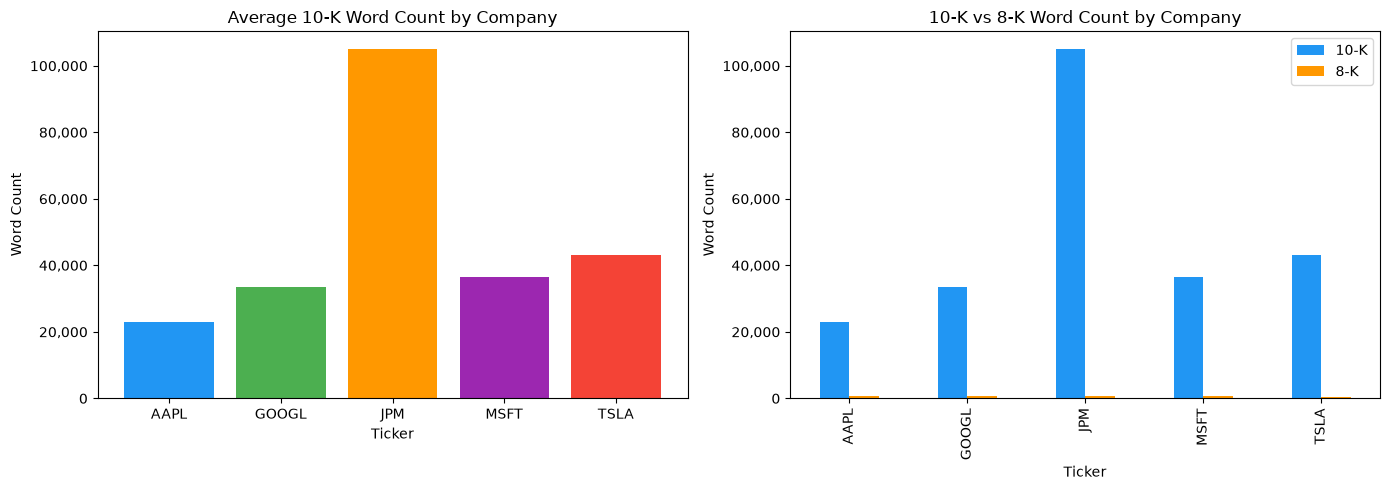

Chart saved.


In [38]:
# visualization

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1 — word counts by ticker for 10-K only
df_10k = df[df["filing_type"] == "10-K"]
axes[0].bar(df_10k.groupby("ticker")["word_count"].mean().index,
            df_10k.groupby("ticker")["word_count"].mean().values,
            color=["#2196F3", "#4CAF50", "#FF9800", "#9C27B0", "#F44336"])
axes[0].set_title("Average 10-K Word Count by Company")
axes[0].set_xlabel("Ticker")
axes[0].set_ylabel("Word Count")
axes[0].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{int(x):,}"))

# Plot 2 — 10-K vs 8-K word count comparison
df.groupby(["ticker", "filing_type"])["word_count"].mean().unstack().plot(
    kind="bar", ax=axes[1], color=["#2196F3", "#FF9800"]
)
axes[1].set_title("10-K vs 8-K Word Count by Company")
axes[1].set_xlabel("Ticker")
axes[1].set_ylabel("Word Count")
axes[1].legend(["10-K", "8-K"])
axes[1].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{int(x):,}"))

plt.tight_layout()
plt.savefig("notebooks/eda_word_counts.png", dpi=150, bbox_inches="tight")
plt.show()
print("Chart saved.")

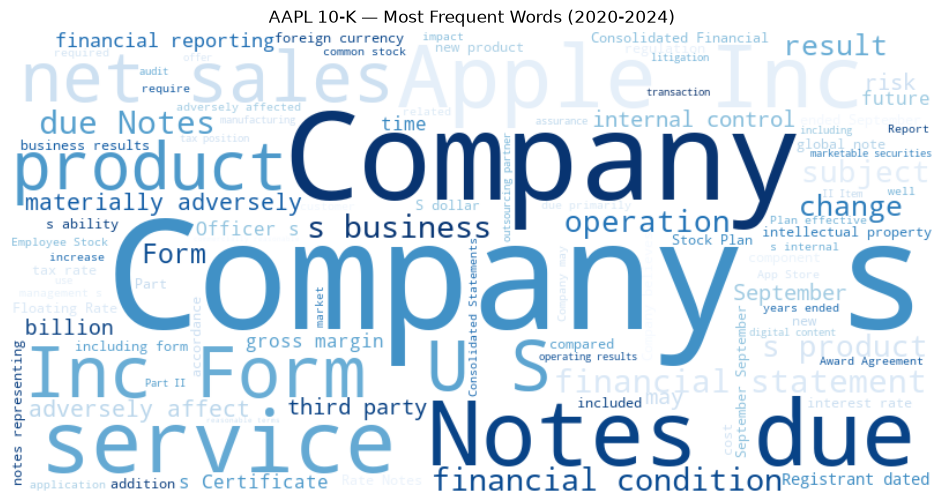

Word cloud saved.


In [39]:
# Word Cloud for 10-K filings AAPl

from wordcloud import WordCloud

# Combining all AAPL 10-K texts into one string
aapl_10k_text = " ".join([
    text for key, text in all_texts.items()
    if "AAPL_10-K" in key
])

# Generate word cloud
wordcloud = WordCloud(
    width=800,
    height=400,
    background_color="white",
    max_words=100,
    stopwords=None,
    colormap="Blues"
).generate(aapl_10k_text)

# Display
plt.figure(figsize=(14, 6))
plt.imshow(wordcloud, interpolation="bilinear")
plt.axis("off")
plt.title("AAPL 10-K — Most Frequent Words (2020-2024)")
plt.savefig("notebooks/eda_wordcloud_aapl.png", dpi=150, bbox_inches="tight")
plt.show()
print("Word cloud saved.")

In [40]:
print(len(all_texts))

125


In [41]:
import pickle

# Save
with open("data/processed/all_texts.pkl", "wb") as f:
    pickle.dump(all_texts, f)

print("Pickle file saved.")

Pickle file saved.
